In [12]:
!pip install librosa soundfile scikit-learn numpy matplotlib seaborn -q

import os, json, zipfile, pickle
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from google.colab import files

In [14]:
SR = 22050
N_MFCC = 40

def extract_features(file_path):
    """
    Extract a flat feature vector from one audio file.
    Returns ~200 numbers: mean+std of MFCC, delta, chroma, spectral features.
    """
    try:
        y, sr = librosa.load(file_path, sr=SR, duration=4.0)
        if len(y) < sr * 0.5:  # skip clips shorter than 0.5s
            return None

        feats = []

        # ── MFCCs (mean + std of each coefficient)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        feats.extend(np.mean(mfcc, axis=1))   # 40 values
        feats.extend(np.std(mfcc,  axis=1))   # 40 values

        # ── Delta MFCCs
        delta_mfcc = librosa.feature.delta(mfcc)
        feats.extend(np.mean(delta_mfcc, axis=1))  # 40
        feats.extend(np.std(delta_mfcc,  axis=1))  # 40

        # ── Spectral features
        spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_bw       = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        spec_rolloff  = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        zcr           = librosa.feature.zero_crossing_rate(y)
        rms           = librosa.feature.rms(y=y)

        for feat in [spec_centroid, spec_bw, spec_rolloff, zcr, rms]:
            feats.append(np.mean(feat))
            feats.append(np.std(feat))

        feats.extend(np.mean(spec_contrast, axis=1))  # 7
        feats.extend(np.std(spec_contrast,  axis=1))  # 7

        # ── Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        feats.extend(np.mean(chroma, axis=1))  # 12
        feats.extend(np.std(chroma,  axis=1))  # 12

        # ── Tonnetz
        try:
            tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
            feats.extend(np.mean(tonnetz, axis=1))  # 6
            feats.extend(np.std(tonnetz,  axis=1))  # 6
        except:
            feats.extend([0]*12)

        return np.array(feats, dtype=np.float32)

    except Exception as e:
        print(f' Error on {file_path}: {e}')
        return None


# ── Load all clips ────────────────────────────────────────
X, y_labels, file_names = [], [], []
CLASS_MAP = {'normal': 0, 'fault': 1}

for cls, label in CLASS_MAP.items():
    folder = f'dataset/{cls}'
    wav_files = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])
    print(f'\n[{cls.upper()}] extracting features from {len(wav_files)} clips...')
    for fname in wav_files:
        path = os.path.join(folder, fname)
        feat = extract_features(path)
        if feat is not None:
            X.append(feat)
            y_labels.append(label)
            file_names.append(fname)

X = np.array(X)
y_labels = np.array(y_labels)

print(f'\n Feature matrix: {X.shape}  (samples × features)')
print(f'   Normal clips : {np.sum(y_labels==0)}')
print(f'   Fault clips  : {np.sum(y_labels==1)}')
print(f'   Feature size : {X.shape[1]} values per clip')


[NORMAL] extracting features from 79 clips...

[FAULT] extracting features from 60 clips...

 Feature matrix: (139, 220)  (samples × features)
   Normal clips : 79
   Fault clips  : 60
   Feature size : 220 values per clip


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

Train: 111 samples
Test : 28 samples


Model: Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        16
       Fault       1.00      1.00      1.00        12

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



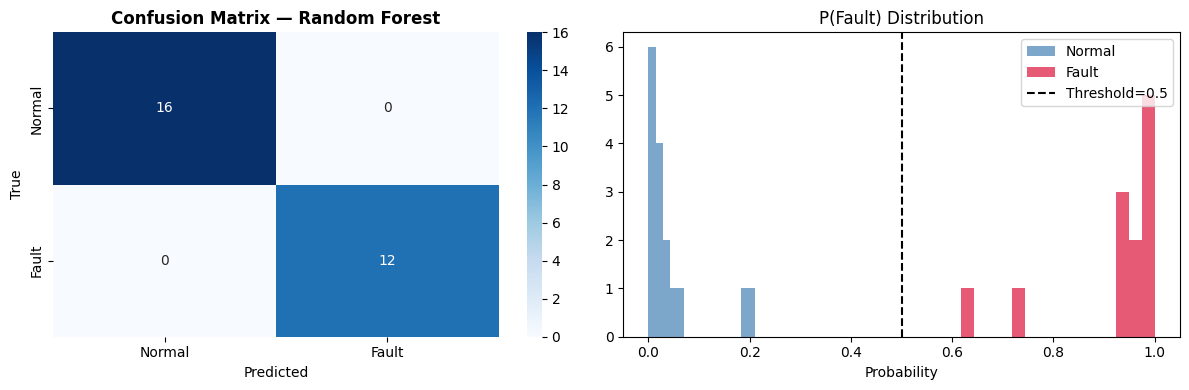

In [16]:
# Train best model on full train set
best_model = models[best_name]
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f'Model: {best_name}')
print('='*45)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fault']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Fault'], yticklabels=['Normal','Fault'])
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Probability distribution
axes[1].hist(y_prob[y_test==0], bins=15, alpha=0.7, color='steelblue', label='Normal')
axes[1].hist(y_prob[y_test==1], bins=15, alpha=0.7, color='crimson',   label='Fault')
axes[1].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[1].set_title('P(Fault) Distribution')
axes[1].set_xlabel('Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

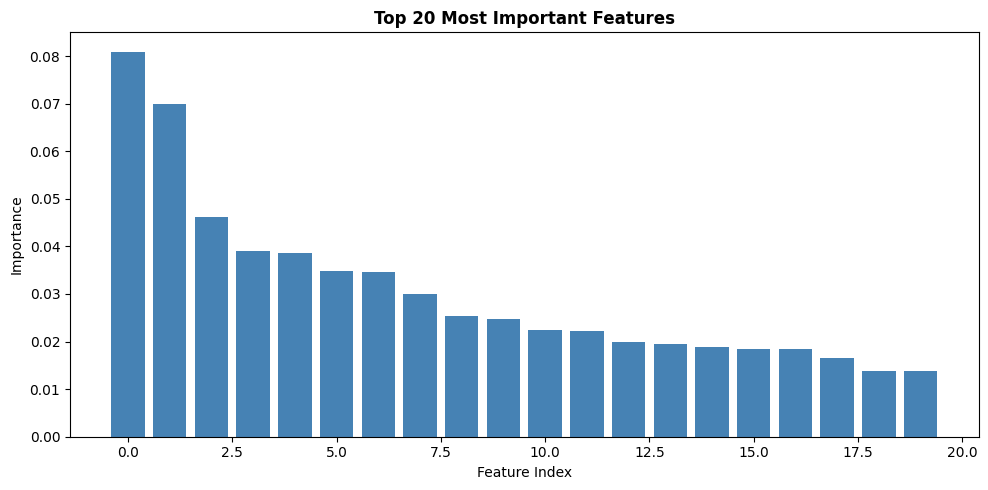

Top feature indices: [ 28 168  25   8  14]


In [9]:
# Only works for RF and GBM
clf = best_model.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    top_n = 20
    top_idx = np.argsort(importances)[-top_n:][::-1]

    plt.figure(figsize=(10, 5))
    plt.bar(range(top_n), importances[top_idx], color='steelblue')
    plt.title(f'Top {top_n} Most Important Features', fontweight='bold')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()
    print(f'Top feature indices: {top_idx[:5]}')
else:
    print('Feature importance not available for this model type.')

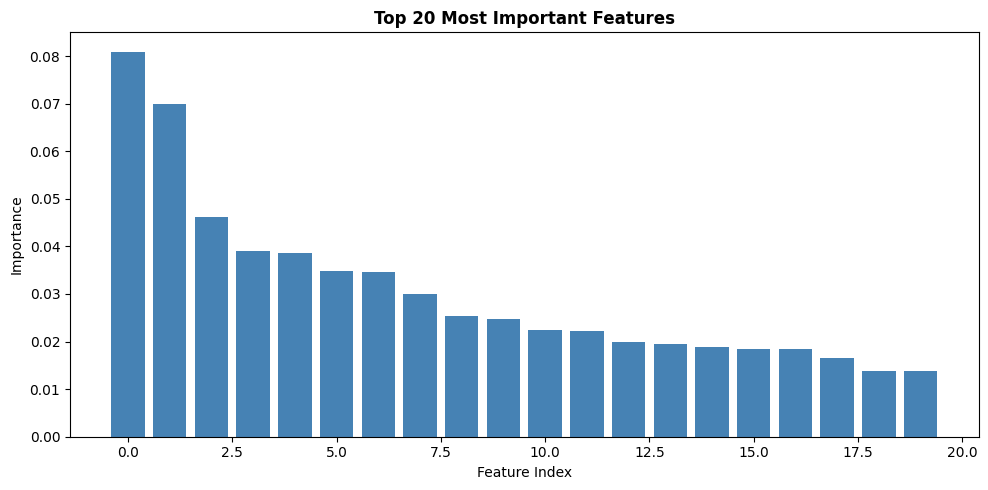

Top feature indices: [ 28 168  25   8  14]


In [17]:
# Only works for RF and GBM
clf = best_model.named_steps['clf']
if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    top_n = 20
    top_idx = np.argsort(importances)[-top_n:][::-1]

    plt.figure(figsize=(10, 5))
    plt.bar(range(top_n), importances[top_idx], color='steelblue')
    plt.title(f'Top {top_n} Most Important Features', fontweight='bold')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()
    print(f'Top feature indices: {top_idx[:5]}')
else:
    print('Feature importance not available for this model type.')

In [18]:
# Save model
with open('fault_detector_rf.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save config
config = {
    'model_type': best_name,
    'sample_rate': SR,
    'n_mfcc': N_MFCC,
    'classes': {0: 'normal', 1: 'fault'},
    'threshold': 0.5,
    'n_features': X.shape[1]
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Saved: fault_detector_rf.pkl')
print('✅ Saved: model_config.json')

files.download('fault_detector_rf.pkl')
files.download('model_config.json')

✅ Saved: fault_detector_rf.pkl
✅ Saved: model_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>